<a href="https://www.kaggle.com/code/lalit7881/global-aviation-industry-2010-26-eda-98?scriptVersionId=335322853" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/passenger_traffic.csv
/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/airline_financials.csv
/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/aviation_incidents.csv
/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/fleet_orders.csv
/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/route_performance.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-aviation-industry-2010-2026/route_performance.csv")

print(df.shape)
print(df.head())
print(df.info())

(400, 11)
   year       route origin_iata destination_iata  distance_km region  \
0  2015  Jeju-Seoul         CJU              GMP          451   Asia   
1  2018  Jeju-Seoul         CJU              GMP          451   Asia   
2  2019  Jeju-Seoul         CJU              GMP          451   Asia   
3  2020  Jeju-Seoul         CJU              GMP          451   Asia   
4  2021  Jeju-Seoul         CJU              GMP          451   Asia   

                  main_airlines  annual_passengers_m  avg_fare_usd  \
0  Korean Air, Asiana, JeJu Air                 6.37          50.0   
1  Korean Air, Asiana, JeJu Air                 7.92          68.0   
2  Korean Air, Asiana, JeJu Air                 7.65          65.0   
3  Korean Air, Asiana, JeJu Air                 2.21          21.0   
4  Korean Air, Asiana, JeJu Air                 3.57          34.0   

   weekly_frequency_est  annual_revenue_usd_m  
0                    19                 320.5  
1                    22                 

In [3]:
df.describe()

,year,distance_km,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,2021.300000,3947.400000,3.910225,177.577500,11.255000,523.404000
std,3.230494,3481.534553,2.770784,135.007004,8.351307,314.916879
min,2015.000000,297.000000,0.330000,19.000000,1.000000,25.500000
25%,2019.000000,1179.500000,1.727500,78.000000,5.000000,283.200000
50%,2021.500000,2328.500000,3.135000,121.000000,9.000000,506.300000
75%,2024.000000,5723.750000,5.710000,254.500000,17.000000,729.800000
max,2026.000000,12057.000000,12.500000,563.000000,37.000000,1413.900000


In [4]:
df.isnull()

,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.columns

Index(['year', 'route', 'origin_iata', 'destination_iata', 'distance_km',
       'region', 'main_airlines', 'annual_passengers_m', 'avg_fare_usd',
       'weekly_frequency_est', 'annual_revenue_usd_m'],
      dtype='object')

In [6]:
df.dtypes

year                      int64
route                    object
origin_iata              object
destination_iata         object
distance_km               int64
region                   object
main_airlines            object
annual_passengers_m     float64
avg_fare_usd            float64
weekly_frequency_est      int64
annual_revenue_usd_m    float64
dtype: object

In [7]:
df.shape

(400, 11)

In [8]:
df.nunique()

year                     10
route                    40
origin_iata              31
destination_iata         29
distance_km              40
region                   14
main_airlines            39
annual_passengers_m     304
avg_fare_usd            243
weekly_frequency_est     36
annual_revenue_usd_m    388
dtype: int64

In [9]:
df.isnull().sum()

year                    0
route                   0
origin_iata             0
destination_iata        0
distance_km             0
region                  0
main_airlines           0
annual_passengers_m     0
avg_fare_usd            0
weekly_frequency_est    0
annual_revenue_usd_m    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## EDA

In [11]:
import matplotlib.ticker as mtick

In [12]:
plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Figure Size
FIGSIZE = (12,6)


In [13]:
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c",
    "#d62728", "#9467bd", "#8c564b",
    "#e377c2", "#7f7f7f", "#bcbd22",
    "#17becf"
]

In [14]:
display(df.describe(include="all"))

,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
count,400.000000,400,400,400,400.000000,400,400,400.000000,400.000000,400.000000,400.000000
unique,NaN,40,31,29,NaN,14,39,NaN,NaN,NaN,NaN
top,NaN,Jeju-Seoul,HND,LHR,NaN,Asia,"British Airways, Virgin",NaN,NaN,NaN,NaN
freq,NaN,10,20,60,NaN,90,20,NaN,NaN,NaN,NaN
mean,2021.300000,NaN,NaN,NaN,3947.400000,NaN,NaN,3.910225,177.577500,11.255000,523.404000
std,3.230494,NaN,NaN,NaN,3481.534553,NaN,NaN,2.770784,135.007004,8.351307,314.916879
min,2015.000000,NaN,NaN,NaN,297.000000,NaN,NaN,0.330000,19.000000,1.000000,25.500000
25%,2019.000000,NaN,NaN,NaN,1179.500000,NaN,NaN,1.727500,78.000000,5.000000,283.200000
50%,2021.500000,NaN,NaN,NaN,2328.500000,NaN,NaN,3.135000,121.000000,9.000000,506.300000
75%,2024.000000,NaN,NaN,NaN,5723.750000,NaN,NaN,5.710000,254.500000,17.000000,729.800000


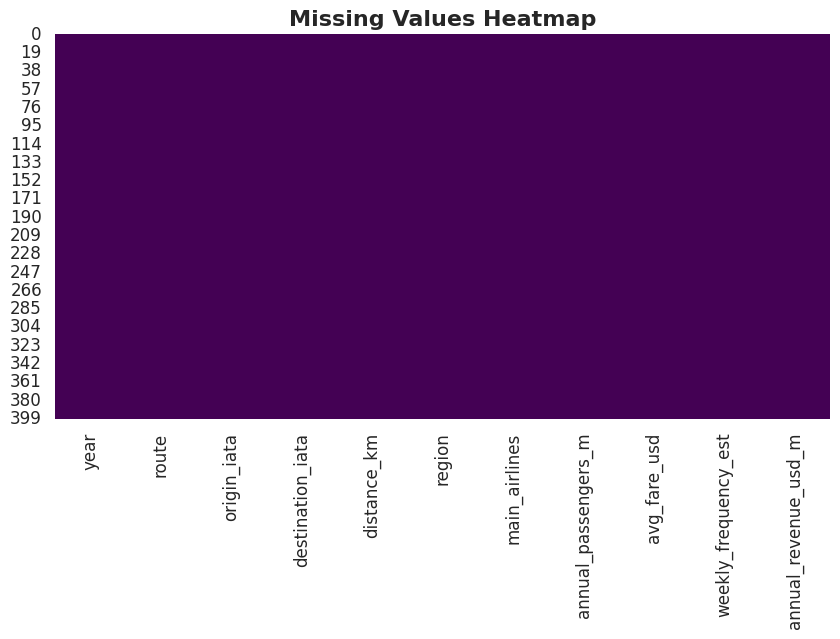

In [15]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=16,
          weight='bold')

plt.show()

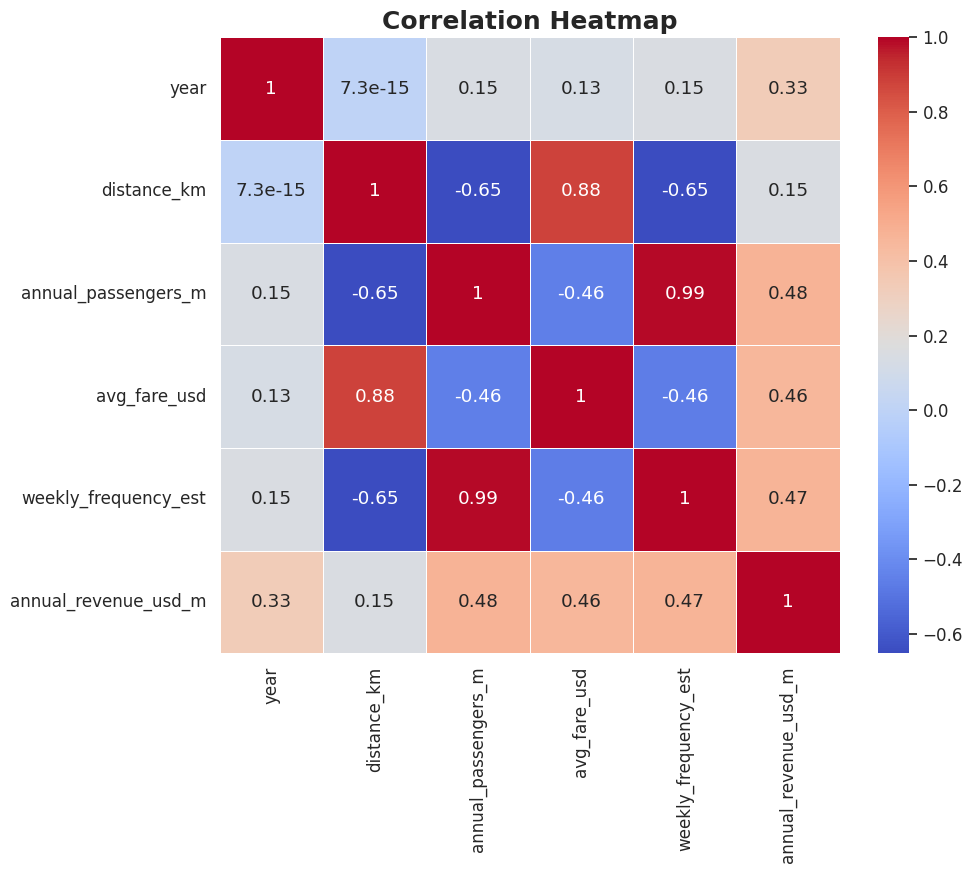

In [16]:
plt.figure(figsize=(10,8))

numeric=df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Correlation Heatmap",
          fontsize=18,
          weight="bold")

plt.show()

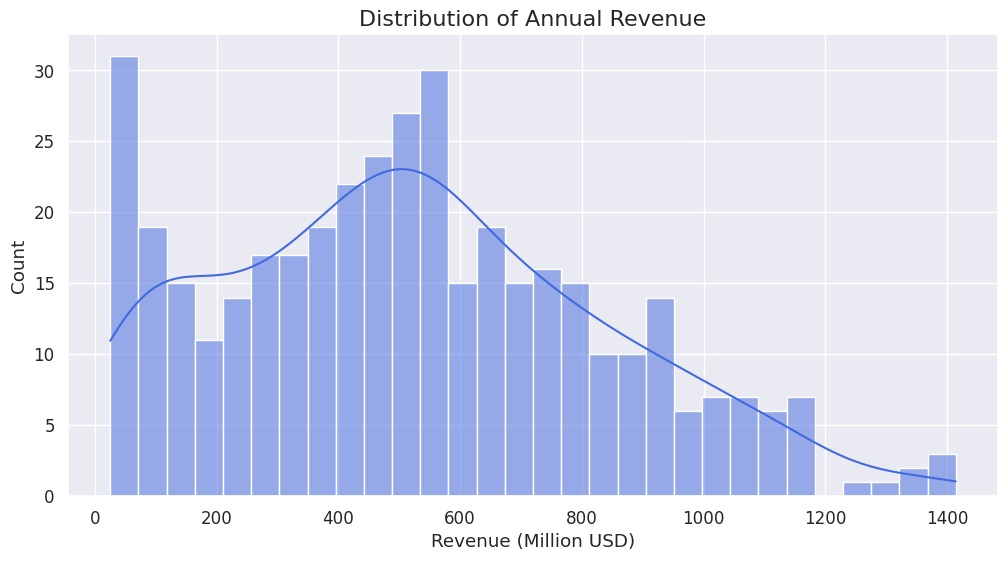

In [17]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    df["annual_revenue_usd_m"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Annual Revenue",
          fontsize=16)

plt.xlabel("Revenue (Million USD)")

plt.show()

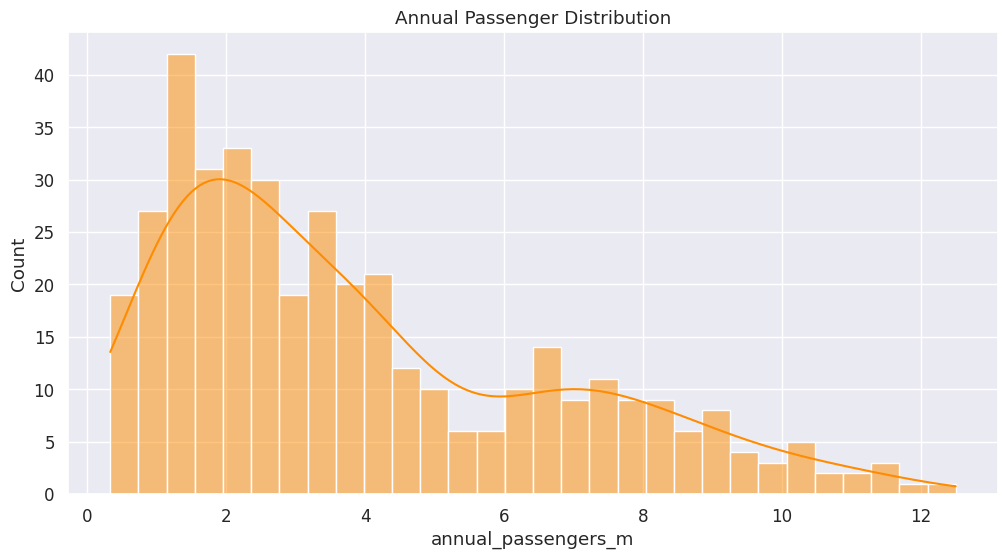

In [18]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    df["annual_passengers_m"],
    bins=30,
    color="darkorange",
    kde=True
)

plt.title("Annual Passenger Distribution")

plt.show()

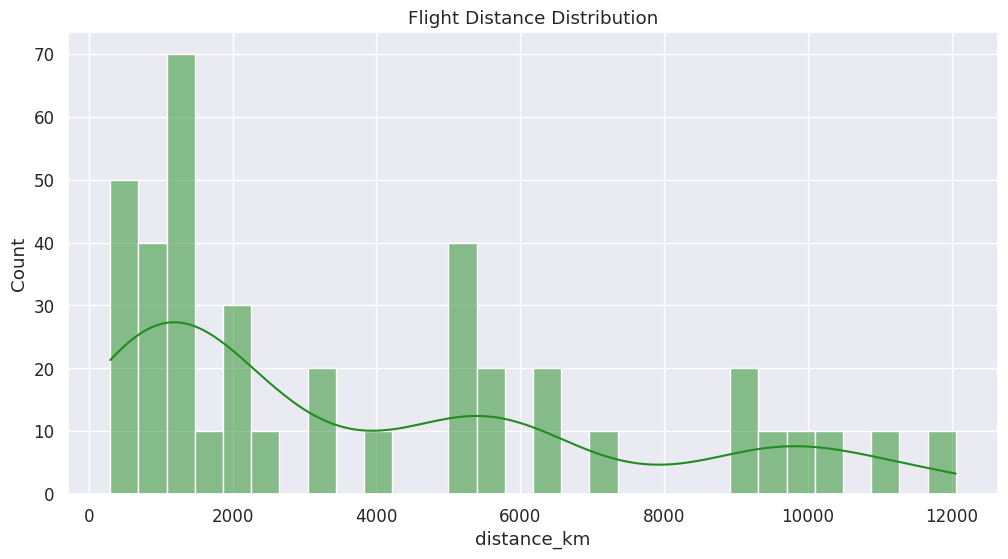

In [19]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    df["distance_km"],
    bins=30,
    color="forestgreen",
    kde=True
)

plt.title("Flight Distance Distribution")

plt.show()

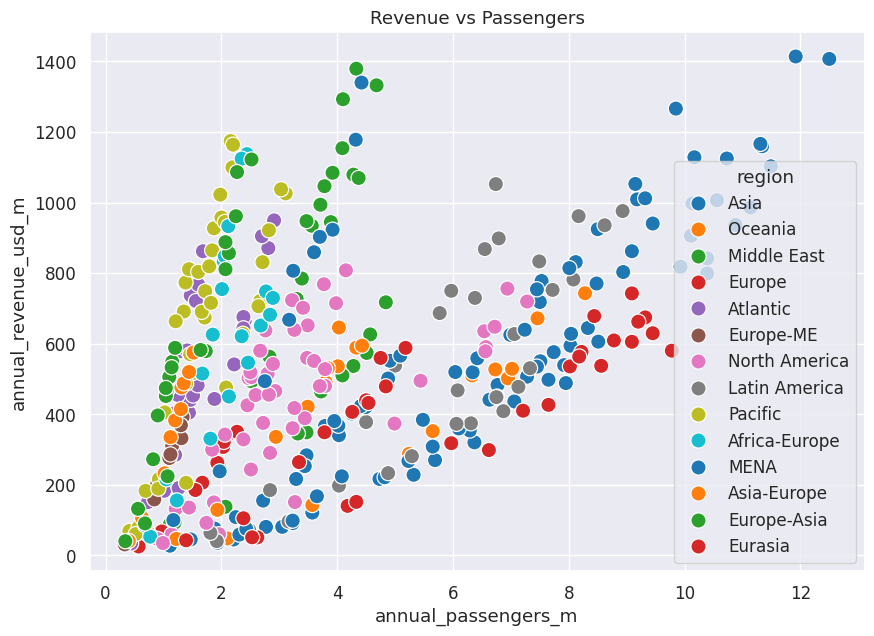

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="annual_passengers_m",
    y="annual_revenue_usd_m",
    hue="region",
    palette="tab10",
    s=120
)

plt.title("Revenue vs Passengers")

plt.show()

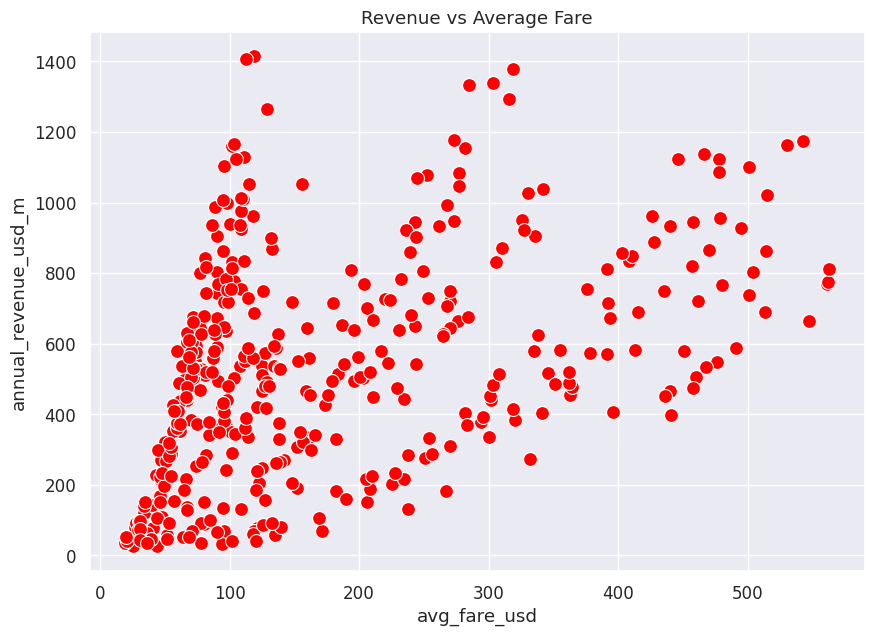

In [21]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="avg_fare_usd",
    y="annual_revenue_usd_m",
    color="red",
    s=100
)

plt.title("Revenue vs Average Fare")

plt.show()

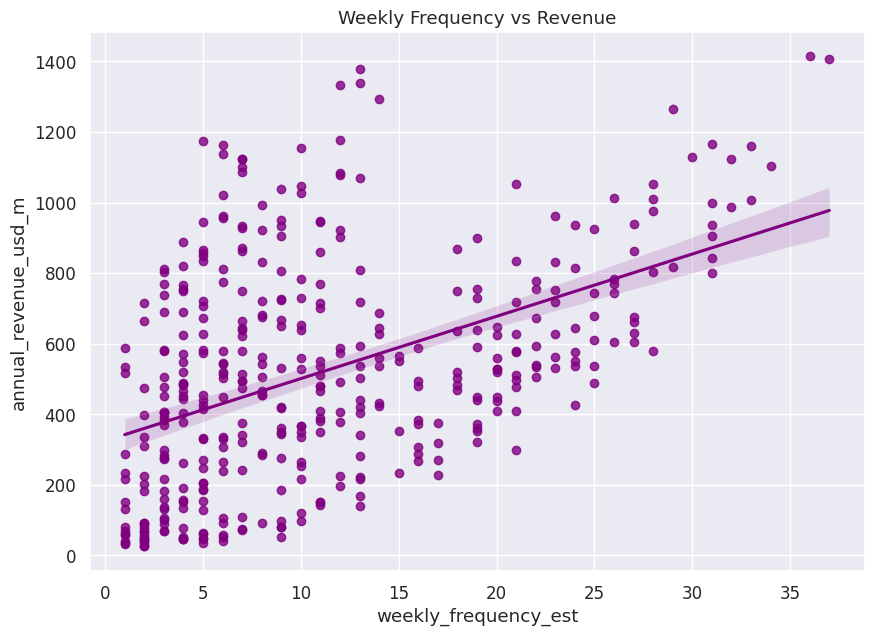

In [22]:
plt.figure(figsize=(10,7))

sns.regplot(
    data=df,
    x="weekly_frequency_est",
    y="annual_revenue_usd_m",
    color="purple"
)

plt.title("Weekly Frequency vs Revenue")

plt.show()

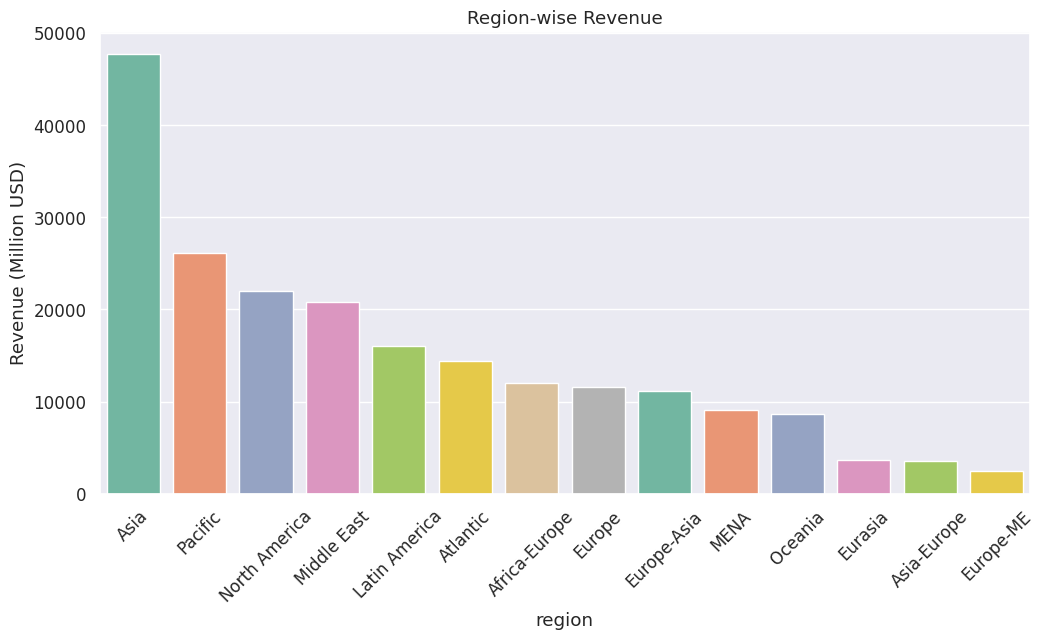

In [23]:
region=df.groupby("region")["annual_revenue_usd_m"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region.index,
    y=region.values,
    palette="Set2"
)

plt.xticks(rotation=45)

plt.title("Region-wise Revenue")

plt.ylabel("Revenue (Million USD)")

plt.show()

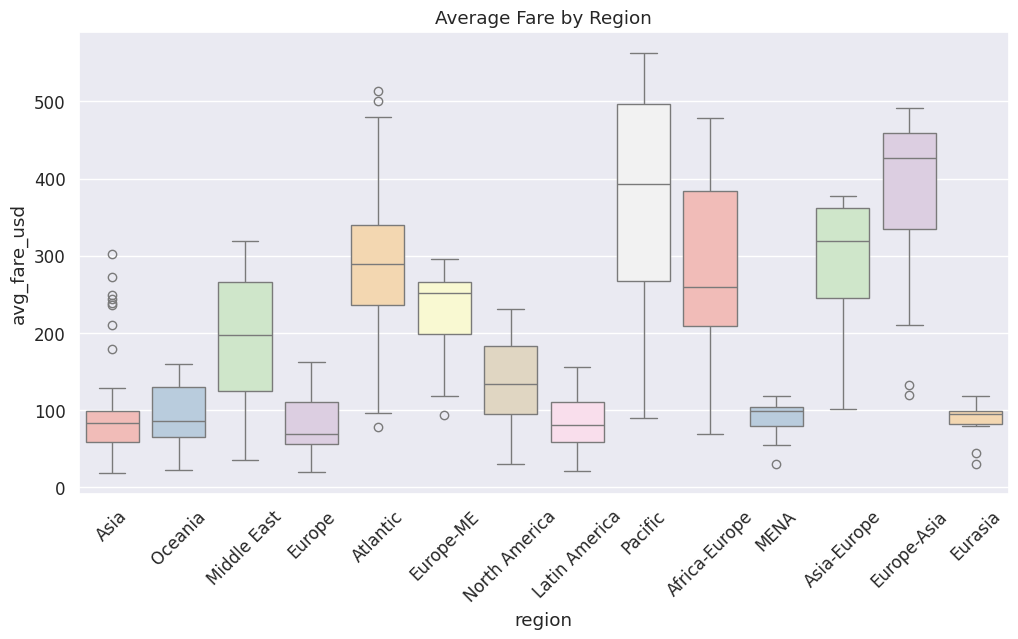

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="region",
    y="avg_fare_usd",
    palette="Pastel1"
)

plt.xticks(rotation=45)

plt.title("Average Fare by Region")

plt.show()

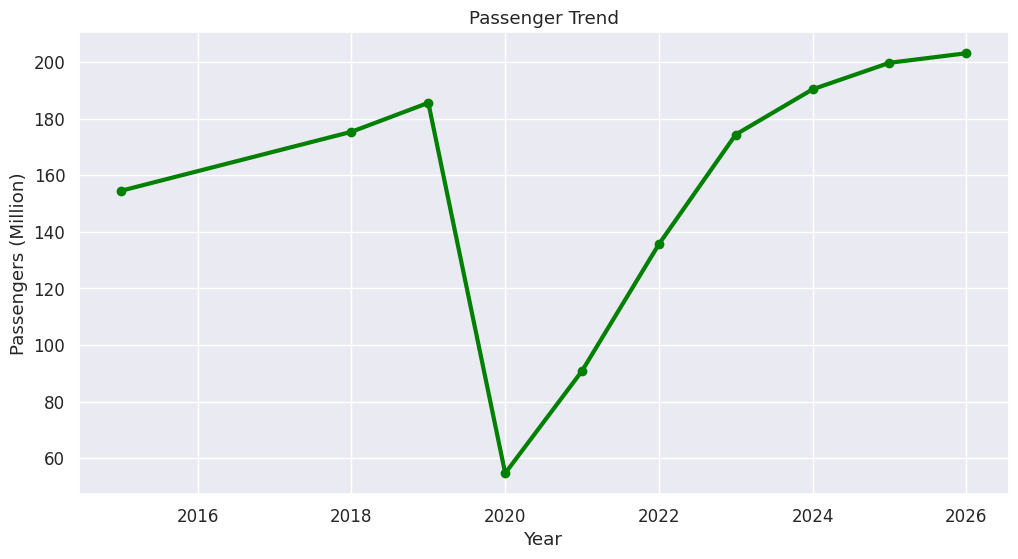

In [25]:
year=df.groupby("year")["annual_passengers_m"].sum()

plt.figure(figsize=(12,6))

plt.plot(
    year.index,
    year.values,
    marker="o",
    linewidth=3,
    color="green"
)

plt.title("Passenger Trend")

plt.xlabel("Year")

plt.ylabel("Passengers (Million)")

plt.grid(True)

plt.show()

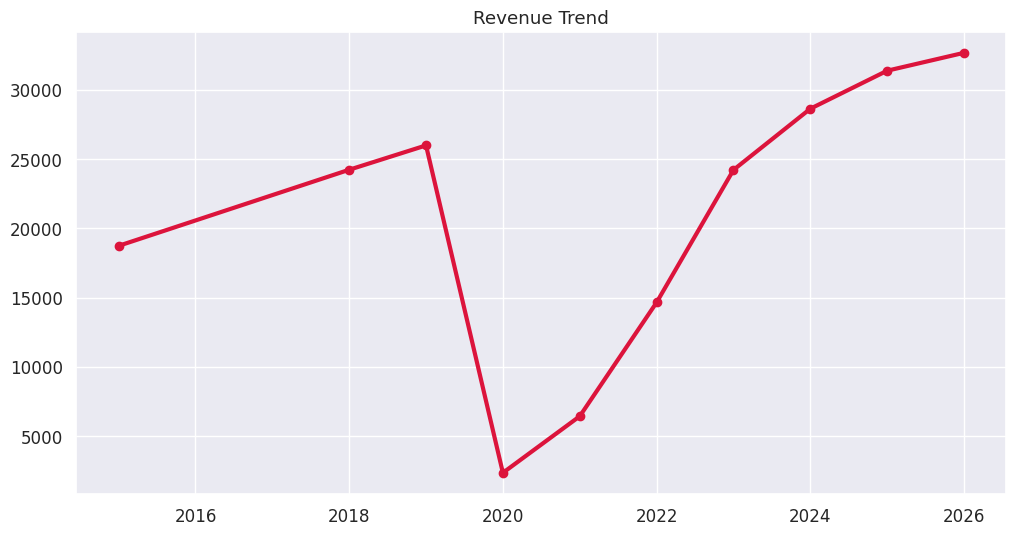

In [26]:
year=df.groupby("year")["annual_revenue_usd_m"].sum()

plt.figure(figsize=(12,6))

plt.plot(
    year.index,
    year.values,
    marker="o",
    color="crimson",
    linewidth=3
)

plt.title("Revenue Trend")

plt.show()

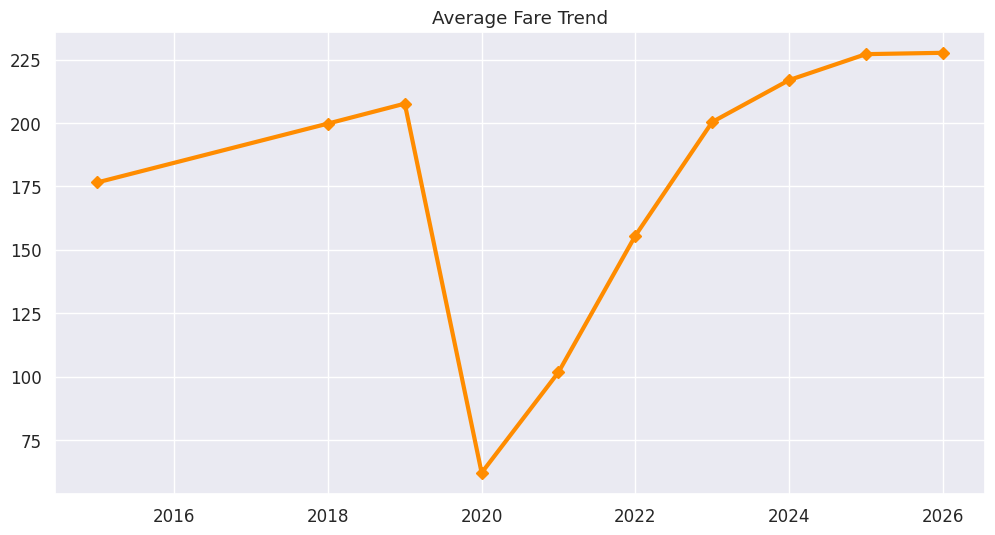

In [27]:
fare=df.groupby("year")["avg_fare_usd"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    fare.index,
    fare.values,
    marker="D",
    color="darkorange",
    linewidth=3
)

plt.title("Average Fare Trend")

plt.show()

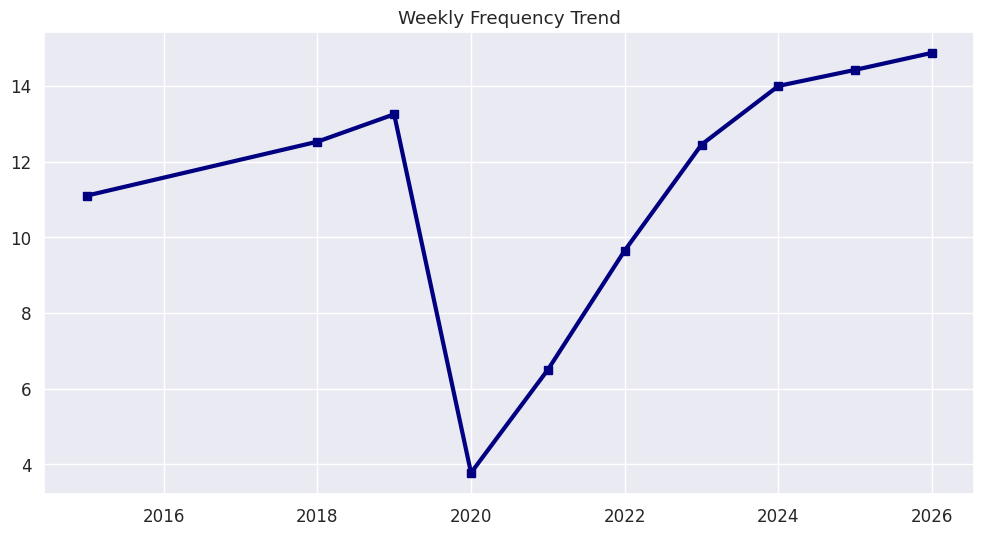

In [28]:
freq=df.groupby("year")["weekly_frequency_est"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    freq.index,
    freq.values,
    marker="s",
    color="navy",
    linewidth=3
)

plt.title("Weekly Frequency Trend")

plt.show()

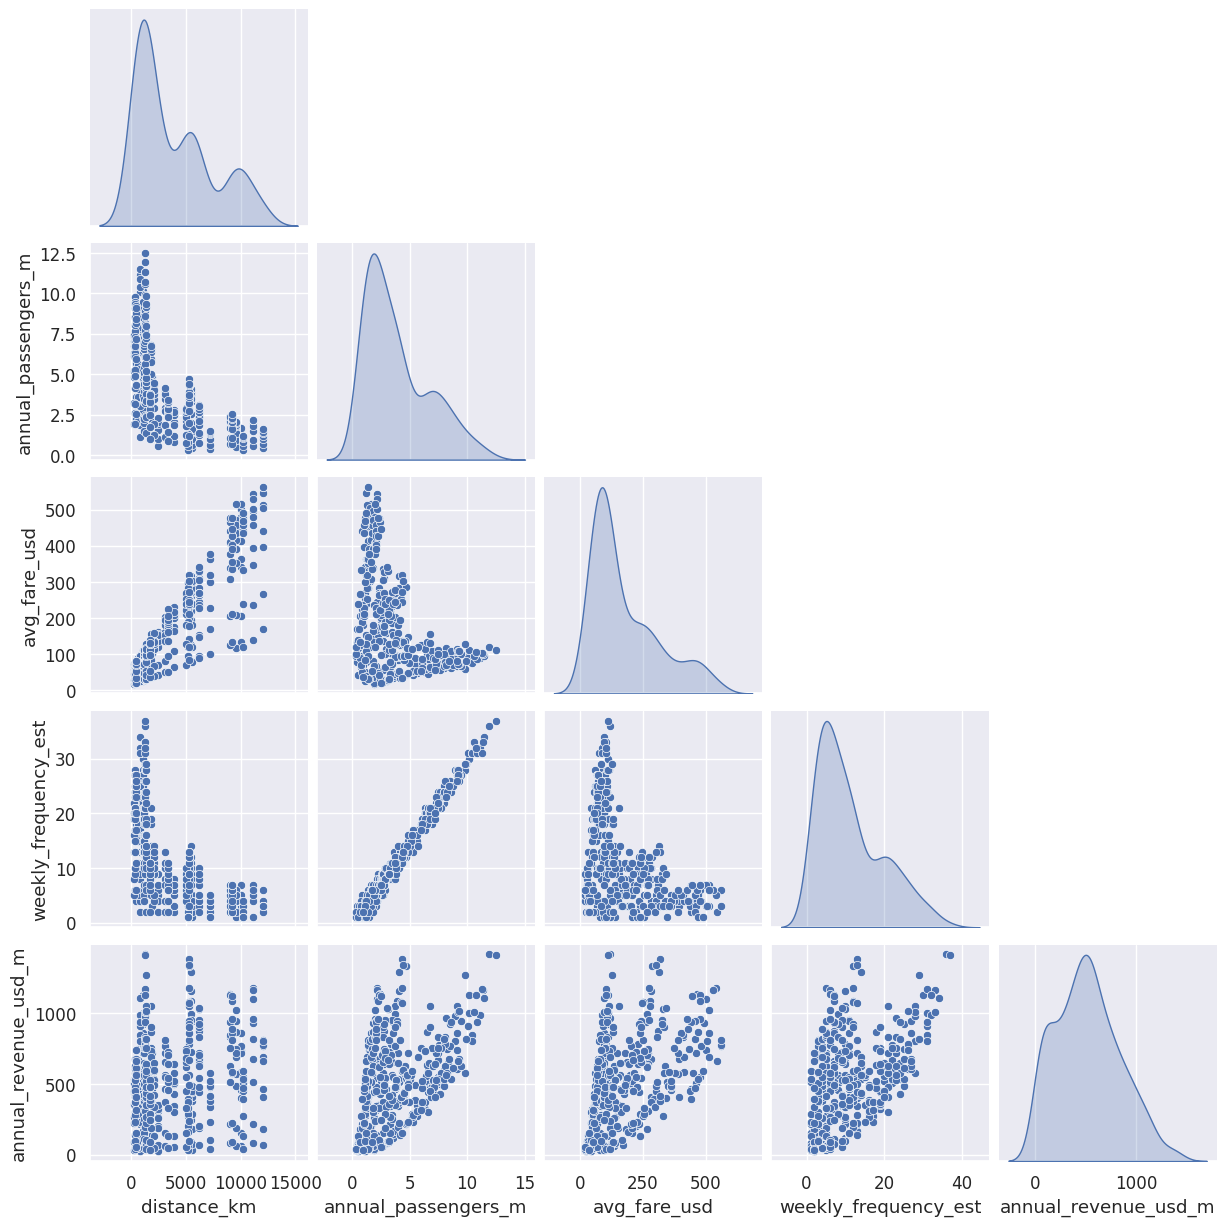

In [29]:
sns.pairplot(
    df[
        [
            "distance_km",
            "annual_passengers_m",
            "avg_fare_usd",
            "weekly_frequency_est",
            "annual_revenue_usd_m"
        ]
    ],
    corner=True,
    diag_kind="kde"
)

plt.show()

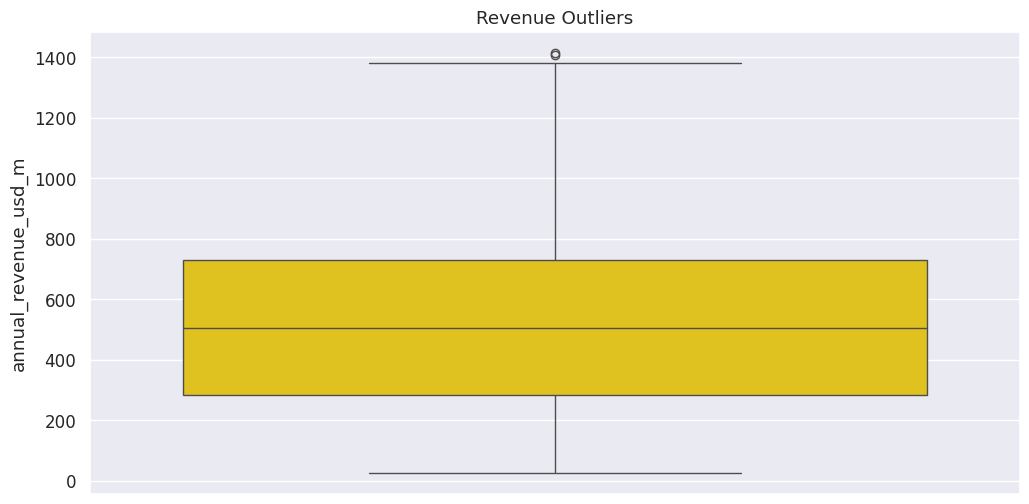

In [30]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    y=df["annual_revenue_usd_m"],
    color="gold"
)

plt.title("Revenue Outliers")

plt.show()

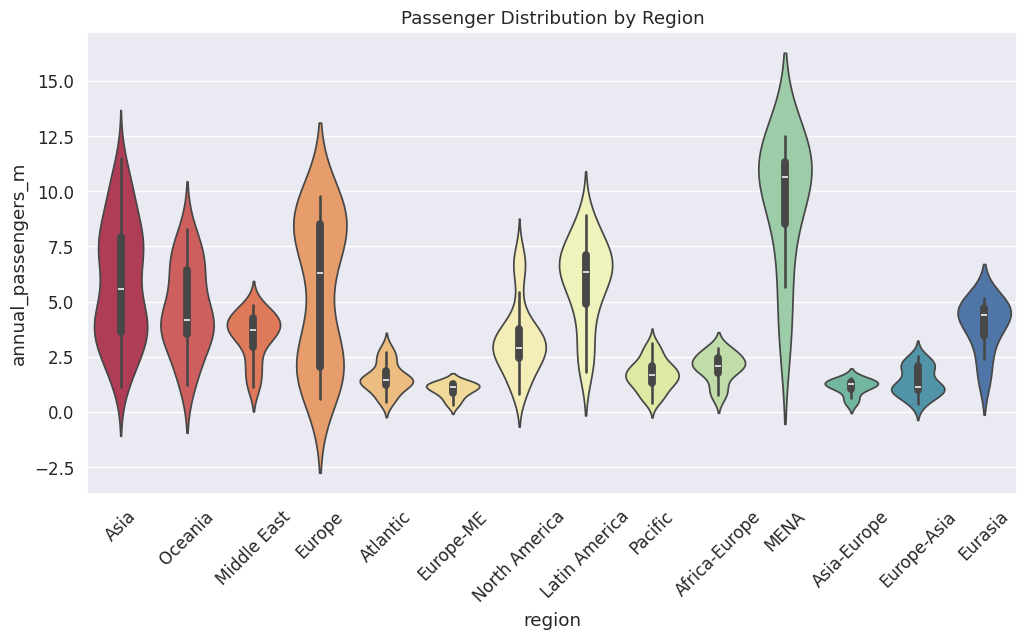

In [31]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="region",
    y="annual_passengers_m",
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Passenger Distribution by Region")

plt.show()

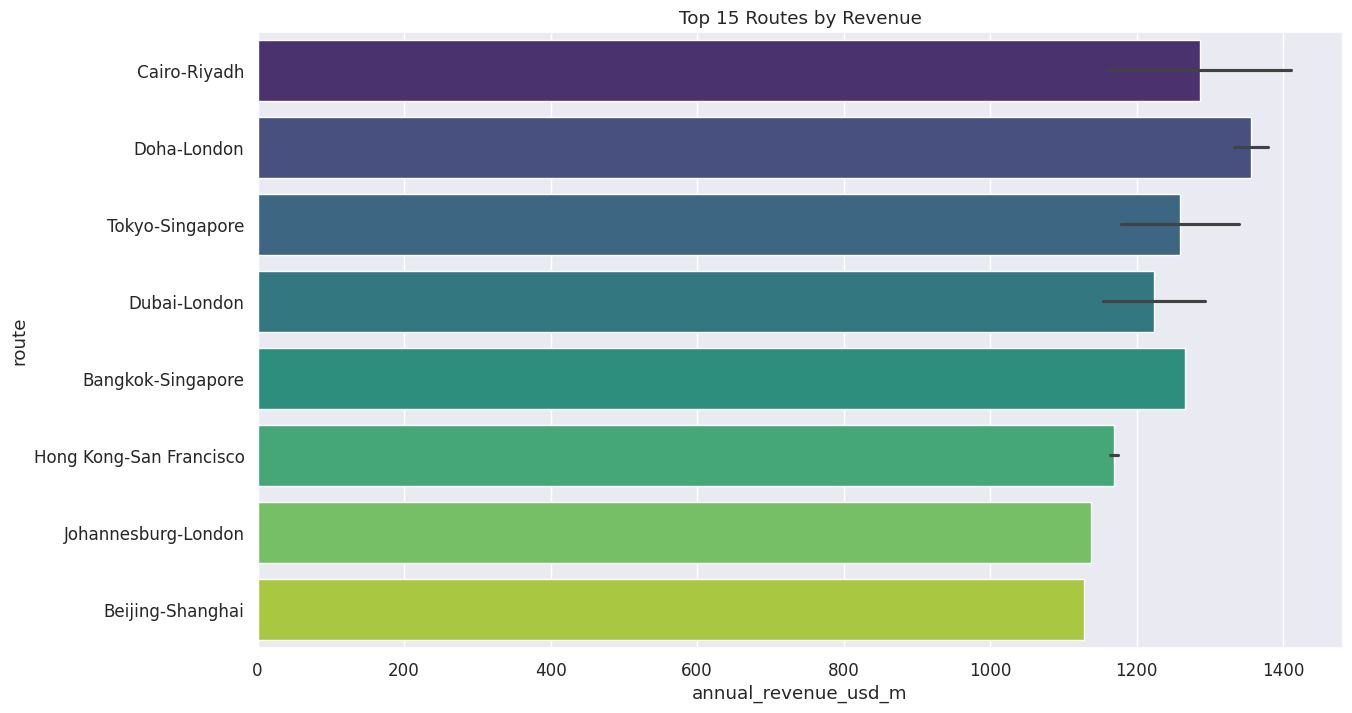

In [32]:
top=df.nlargest(15,"annual_revenue_usd_m")

plt.figure(figsize=(14,8))

sns.barplot(
    data=top,
    y="route",
    x="annual_revenue_usd_m",
    palette="viridis"
)

plt.title("Top 15 Routes by Revenue")

plt.show()

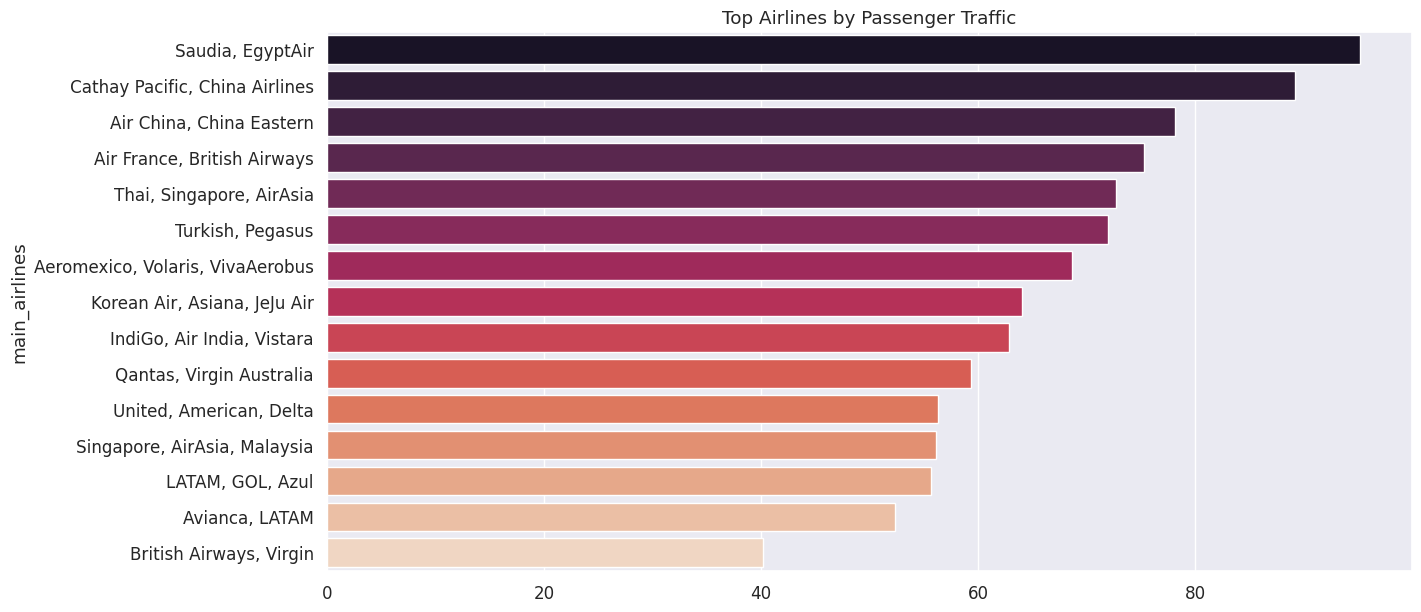

In [33]:
airline=df.groupby("main_airlines")["annual_passengers_m"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=airline.values,
    y=airline.index,
    palette="rocket"
)

plt.title("Top Airlines by Passenger Traffic")

plt.show()

## Feature engineering

In [34]:
TARGET = "annual_revenue_usd_m"

In [35]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

In [36]:
df_fe = df.copy()

# Example feature engineering
df_fe["route_length"] = pd.cut(
    df_fe["distance_km"],
    bins=[0,1500,4000,7000,20000],
    labels=["Short","Medium","Long","Ultra Long"]
)

df_fe["num_airlines"] = df_fe["main_airlines"].str.split(",").apply(len)

df_fe["passengers_per_flight"] = (
    df_fe["annual_passengers_m"]*1000000 /
    (df_fe["weekly_frequency_est"]*52)
)

df_fe["fare_distance"] = (
    df_fe["avg_fare_usd"] *
    df_fe["distance_km"]
)

df_fe["route_popularity"] = (
    df_fe["annual_passengers_m"] *
    df_fe["weekly_frequency_est"]
)

# Copy for ML
df_ml = df_fe.copy()

In [37]:
encoder = LabelEncoder()

categorical_columns = df_ml.select_dtypes(
    include=["object","category"]
).columns

for col in categorical_columns:

    df_ml[col] = encoder.fit_transform(
        df_ml[col].astype(str)
    )

print("Label Encoding Completed")

display(df_ml.head())

Label Encoding Completed


,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m,route_length,num_airlines,passengers_per_flight,fare_distance,route_popularity
0,2015,16,7,12,451,1,24,6.37,50.0,19,320.5,2,3,6447.368421,22550.0,121.03
1,2018,16,7,12,451,1,24,7.92,68.0,22,539.4,2,3,6923.076923,30668.0,174.24
2,2019,16,7,12,451,1,24,7.65,65.0,21,498.0,2,3,7005.494505,29315.0,160.65
3,2020,16,7,12,451,1,24,2.21,21.0,4,45.4,2,3,10625.000000,9471.0,8.84
4,2021,16,7,12,451,1,24,3.57,34.0,10,121.5,2,3,6865.384615,15334.0,35.70


In [38]:
X = df_ml.drop(columns=[TARGET])

y = df_ml[TARGET]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (400, 15)
Target Shape : (400,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (320, 15)
Testing Shape : (80, 15)


In [40]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostRegressor(
            random_state=42
        ),

    "KNN":
        KNeighborsRegressor(),

    "Support Vector Regressor":
        SVR(),

    "XGBoost":
        XGBRegressor(
            random_state=42,
            objective="reg:squarederror"
        ),

    "LightGBM":
        LGBMRegressor(
            random_state=42
        ),

    "CatBoost":
        CatBoostRegressor(
            verbose=0,
            random_state=42
        )
}

In [41]:
results = []

for name, model in models.items():

    print("="*60)

    print(name)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    results.append([

        name,

        r2,

        mae,

        mse,

        rmse

    ])

    print("R2 Score :", round(r2,4))

    print("MAE :", round(mae,4))

    print("RMSE :", round(rmse,4))

Linear Regression
R2 Score : 0.897
MAE : 82.4339
RMSE : 105.3663
Decision Tree
R2 Score : 0.8965
MAE : 82.29
RMSE : 105.6127
Random Forest
R2 Score : 0.9166
MAE : 70.4732
RMSE : 94.8031
Extra Trees
R2 Score : 0.9865
MAE : 29.5712
RMSE : 38.1886
Gradient Boosting
R2 Score : 0.9668
MAE : 42.091
RMSE : 59.8148
AdaBoost
R2 Score : 0.8712
MAE : 102.6453
RMSE : 117.7898
KNN
R2 Score : 0.2551
MAE : 234.292
RMSE : 283.2846
Support Vector Regressor
R2 Score : -0.0074
MAE : 267.1863
RMSE : 329.4395
XGBoost
R2 Score : 0.9469
MAE : 50.6648
RMSE : 75.623
LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 757
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 15
[LightGBM] [Info] Start training from score 514.955624
[LightGBM] [Warning] No further splits

In [42]:
results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "R2 Score",

        "MAE",

        "MSE",

        "RMSE"

    ]

)

results.sort_values(

    by="R2 Score",

    ascending=False,

    inplace=True

)

display(results)

,Model,R2 Score,MAE,MSE,RMSE
3,Extra Trees,0.986464,29.571171,1458.370193,38.188613
10,CatBoost,0.984687,29.957561,1649.819042,40.617965
9,LightGBM,0.969567,42.414416,3278.705436,57.259981
4,Gradient Boosting,0.966791,42.091016,3577.812949,59.814822
8,XGBoost,0.946918,50.664795,5718.836390,75.622989
2,Random Forest,0.916578,70.473242,8987.622667,94.803073
0,Linear Regression,0.896952,82.433947,11102.053821,105.366284
1,Decision Tree,0.896469,82.290000,11154.043500,105.612705
5,AdaBoost,0.871219,102.645254,13874.437162,117.789801
6,KNN,0.255125,234.292000,80250.140810,283.284558


In [43]:
best_model = results.iloc[0]

print("="*50)

print("Best Model")

print("="*50)

display(best_model)

Best Model


Model       Extra Trees
R2 Score       0.986464
MAE           29.571171
MSE         1458.370193
RMSE          38.188613
Name: 3, dtype: object

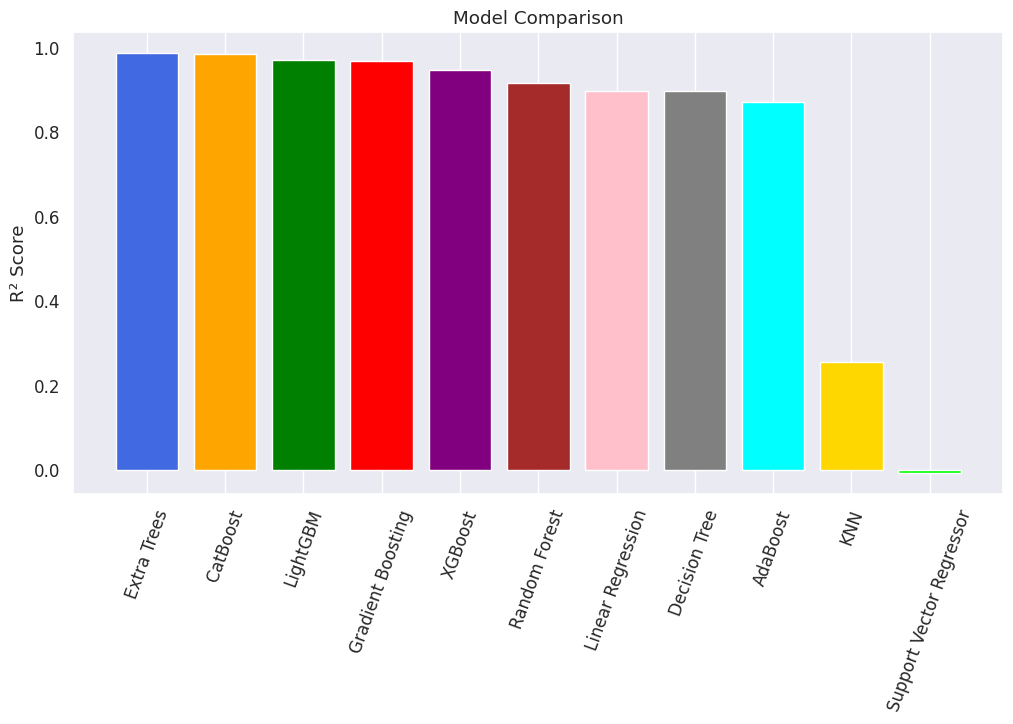

In [44]:
plt.figure(figsize=(12,6))

plt.bar(
    results["Model"],
    results["R2 Score"],
    color=[
        "royalblue",
        "orange",
        "green",
        "red",
        "purple",
        "brown",
        "pink",
        "gray",
        "cyan",
        "gold",
        "lime"
    ]
)

plt.xticks(rotation=70)

plt.ylabel("R² Score")

plt.title("Model Comparison")

plt.grid(axis="y")

plt.show()

In [45]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=300
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(importance.head(20))

,Feature,Importance
0,year,0.527805
1,route,0.128177
8,avg_fare_usd,0.078901
7,annual_passengers_m,0.070832
14,route_popularity,0.041243
5,region,0.025036
3,destination_iata,0.024886
9,weekly_frequency_est,0.020194
13,fare_distance,0.020012
4,distance_km,0.019298


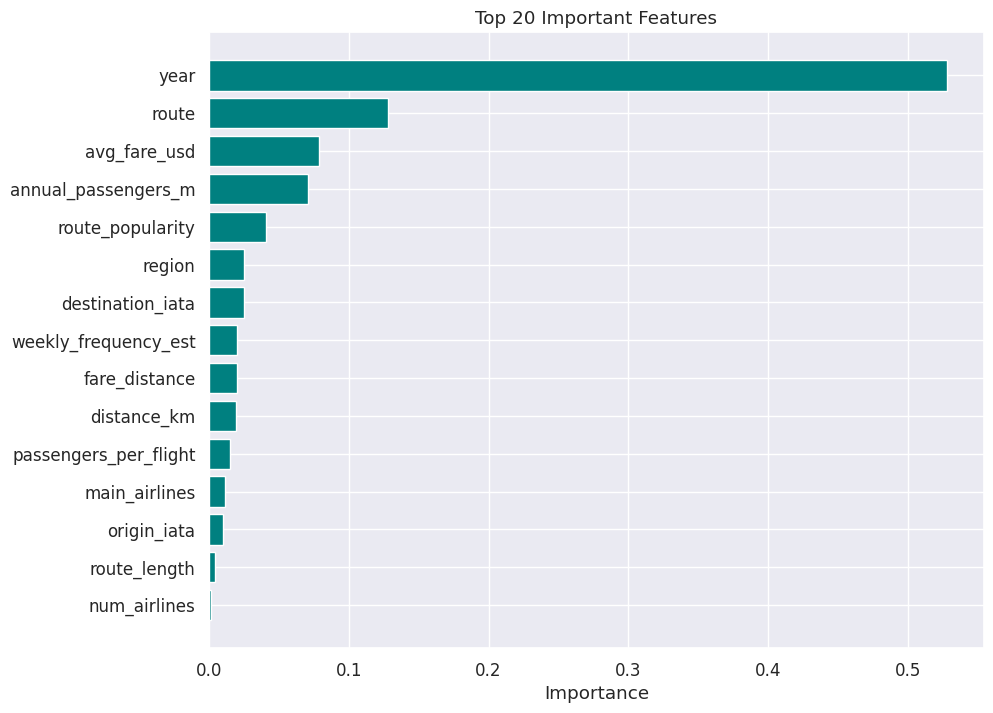

In [46]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20],

    color="teal"

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

## Thank you...pls upvote!!!!!!!!!!